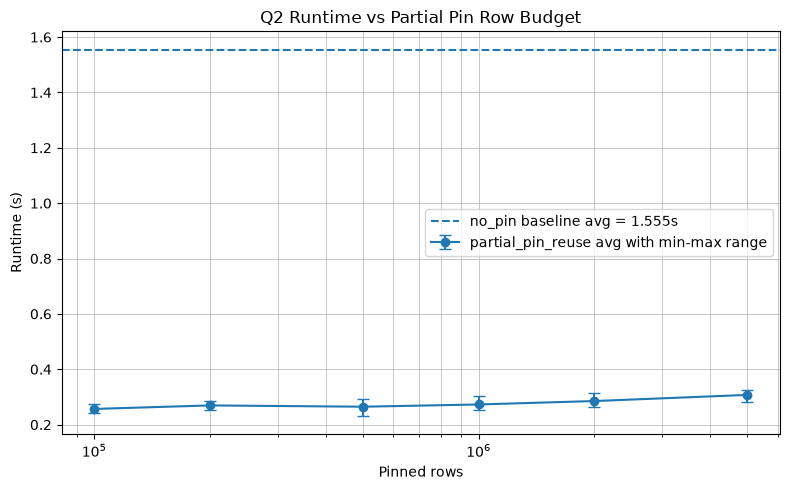

saved: /home/dy1013/sirius_multi-gpu/experiment/fixed_page_hot_sweep_20260702/figures/q2_runtime_vs_rows.png


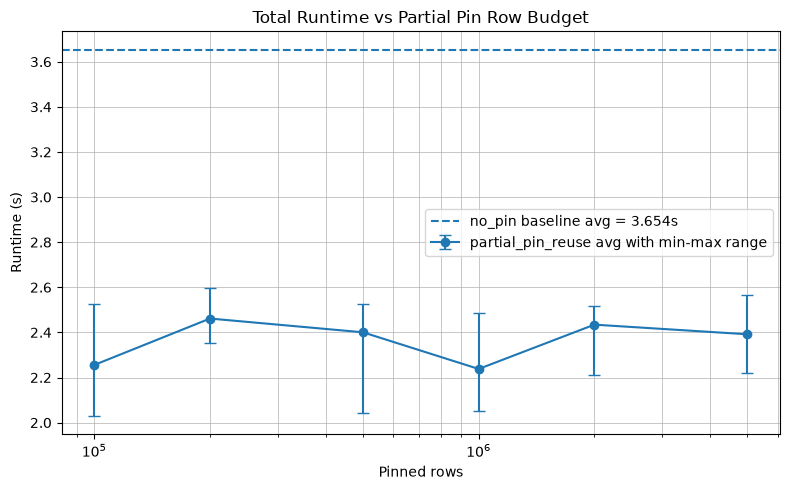

saved: /home/dy1013/sirius_multi-gpu/experiment/fixed_page_hot_sweep_20260702/figures/total_runtime_vs_rows.png


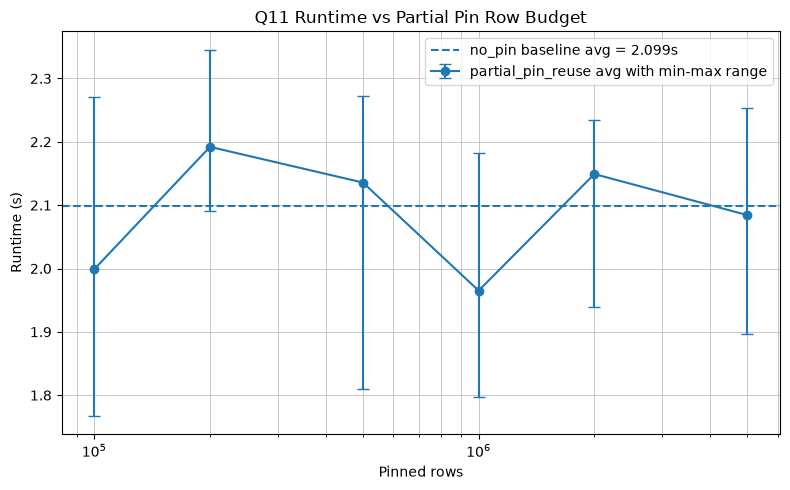

saved: /home/dy1013/sirius_multi-gpu/experiment/fixed_page_hot_sweep_20260702/figures/q11_runtime_vs_rows.png
[Best q2]
n_rows: 100000
avg_s : 0.256752
min_s : 0.242468
max_s : 0.273048
speedup_vs_no_pin_avg: 6.0549x

[Best total]
n_rows: 1000000
avg_s : 2.237923
min_s : 2.052412
max_s : 2.485428
speedup_vs_no_pin_avg: 1.6326x

[Best q11]
n_rows: 1000000
avg_s : 1.965058
min_s : 1.797141
max_s : 2.181685
speedup_vs_no_pin_avg: 1.0682x



In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


SUMMARY_CSV = Path("/home/dy1013/sirius_multi-gpu/experiment/fixed_page_hot_sweep_20260702/summary_min_max_avg.csv")
OUT_DIR = Path("/home/dy1013/sirius_multi-gpu/experiment/fixed_page_hot_sweep_20260702/figures")

OUT_DIR.mkdir(parents=True, exist_ok=True)


df = pd.read_csv(SUMMARY_CSV)

df["n_rows"] = pd.to_numeric(df["n_rows"], errors="coerce")
df["min_s"] = pd.to_numeric(df["min_s"], errors="coerce")
df["max_s"] = pd.to_numeric(df["max_s"], errors="coerce")
df["avg_s"] = pd.to_numeric(df["avg_s"], errors="coerce")
df["speedup_vs_no_pin_avg"] = pd.to_numeric(
    df["speedup_vs_no_pin_avg"],
    errors="coerce",
)


METRICS = {
    "q2": {
        "title": "Q2 Runtime vs Partial Pin Row Budget",
        "filename": "q2_runtime_vs_rows.png",
    },
    "total": {
        "title": "Total Runtime vs Partial Pin Row Budget",
        "filename": "total_runtime_vs_rows.png",
    },
    "q11": {
        "title": "Q11 Runtime vs Partial Pin Row Budget",
        "filename": "q11_runtime_vs_rows.png",
    },
}


def plot_runtime(df: pd.DataFrame, metric: str, out_dir: Path) -> Path:
    partial = (
        df[
            (df["condition"] == "partial_pin_reuse")
            & (df["metric"] == metric)
        ]
        .copy()
        .sort_values("n_rows")
    )

    baseline_values = df[
        (df["condition"] == "no_pin")
        & (df["metric"] == metric)
    ]["avg_s"]

    if baseline_values.empty:
        raise ValueError(f"No no_pin baseline found for metric={metric}")

    if partial.empty:
        raise ValueError(f"No partial_pin_reuse data found for metric={metric}")

    baseline = baseline_values.iloc[0]

    partial["n_rows"] = partial["n_rows"].astype(int)

    yerr_lower = partial["avg_s"] - partial["min_s"]
    yerr_upper = partial["max_s"] - partial["avg_s"]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(
        partial["n_rows"],
        partial["avg_s"],
        yerr=[yerr_lower, yerr_upper],
        marker="o",
        capsize=4,
        label="partial_pin_reuse avg with min-max range",
    )

    ax.axhline(
        baseline,
        linestyle="--",
        label=f"no_pin baseline avg = {baseline:.3f}s",
    )

    ax.set_xscale("log")
    ax.set_xlabel("Pinned rows")
    ax.set_ylabel("Runtime (s)")
    ax.set_title(METRICS[metric]["title"])
    ax.grid(True, which="both", linewidth=0.5)
    ax.legend()

    fig.tight_layout()

    out_path = out_dir / METRICS[metric]["filename"]
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

    print(f"saved: {out_path}")

    return out_path


for metric in ["q2", "total", "q11"]:
    plot_runtime(df, metric, OUT_DIR)


partial = df[df["condition"] == "partial_pin_reuse"].copy()

for metric in ["q2", "total", "q11"]:
    best = (
        partial[partial["metric"] == metric]
        .sort_values("avg_s")
        .iloc[0]
    )

    print(f"[Best {metric}]")
    print(f"n_rows: {int(best['n_rows'])}")
    print(f"avg_s : {best['avg_s']:.6f}")
    print(f"min_s : {best['min_s']:.6f}")
    print(f"max_s : {best['max_s']:.6f}")

    if pd.notna(best["speedup_vs_no_pin_avg"]):
        print(f"speedup_vs_no_pin_avg: {best['speedup_vs_no_pin_avg']:.4f}x")

    print()